In [5]:
#Load and validate saved modeling artifacts

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import sklearn

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted

# 1. Recreate the custom transformer definition

class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """
    Converts categorical values to strings and groups categories
    occurring fewer than min_frequency times into __RARE__.
    """

    def __init__(
        self,
        min_frequency=10,
        rare_label="__RARE__"
    ):
        self.min_frequency = min_frequency
        self.rare_label = rare_label

    def fit(self, X, y=None):
        X_array = np.asarray(
            X,
            dtype=object
        ).astype(str)

        if X_array.ndim != 2:
            raise ValueError(
                "RareCategoryGrouper expects a two-dimensional input."
            )

        self.n_features_in_ = X_array.shape[1]
        self.frequent_categories_ = []

        for column_index in range(self.n_features_in_):
            category_counts = pd.Series(
                X_array[:, column_index]
            ).value_counts(dropna=False)

            frequent_categories = set(
                category_counts[
                    category_counts >= self.min_frequency
                ].index.tolist()
            )

            self.frequent_categories_.append(
                frequent_categories
            )

        return self

    def transform(self, X):
        check_is_fitted(
            self,
            attributes=["frequent_categories_"]
        )

        X_array = np.asarray(
            X,
            dtype=object
        ).astype(str)

        if X_array.ndim != 2:
            raise ValueError(
                "RareCategoryGrouper expects a two-dimensional input."
            )

        if X_array.shape[1] != self.n_features_in_:
            raise ValueError(
                "The number of categorical columns differs "
                "from the fitted data."
            )

        for column_index, frequent_categories in enumerate(
            self.frequent_categories_
        ):
            column_values = X_array[:, column_index]

            frequent_mask = np.fromiter(
                (
                    value in frequent_categories
                    for value in column_values
                ),
                dtype=bool,
                count=len(column_values)
            )

            column_values[~frequent_mask] = self.rare_label
            X_array[:, column_index] = column_values

        return X_array

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.asarray(
                [
                    f"x{index}"
                    for index in range(self.n_features_in_)
                ],
                dtype=object
            )

        return np.asarray(
            input_features,
            dtype=object
        )

# 2. Locate the project root automatically

CURRENT_DIRECTORY = Path.cwd().resolve()

candidate_directories = [
    CURRENT_DIRECTORY,
    *CURRENT_DIRECTORY.parents
]

PROJECT_ROOT = None

for candidate in candidate_directories:
    expected_dataset = (
        candidate
        / "data"
        / "processed"
        / "diabetic_modeling_data_final.csv"
    )

    if expected_dataset.exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the hospital readmission project root.\n"
        f"Current working directory: {CURRENT_DIRECTORY}"
    )

print(f"Current working directory: {CURRENT_DIRECTORY}")
print(f"Project root detected: {PROJECT_ROOT}")

# 3. Define saved artifact paths

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "diabetic_modeling_data_final.csv"
)

SCHEMA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "model_feature_schema.json"
)

SPLIT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "patient_split_assignments.csv"
)

PREPROCESSOR_PATH = (
    PROJECT_ROOT
    / "models"
    / "notebook_4_fitted_preprocessor.joblib"
)

BASELINE_RESULTS_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "metrics"
    / "notebook_4_baseline_model_comparison.csv"
)

BASELINE_METADATA_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "notebook_4_baseline_metadata.json"
)

required_files = {
    "Final modeling dataset": DATA_PATH,
    "Feature schema": SCHEMA_PATH,
    "Patient split assignments": SPLIT_PATH,
    "Fitted preprocessing pipeline": PREPROCESSOR_PATH,
    "Baseline comparison results": BASELINE_RESULTS_PATH,
    "Notebook 4 baseline metadata": BASELINE_METADATA_PATH,
}

# 4. Confirm that all required files exist

missing_files = [
    f"{name}: {path}"
    for name, path in required_files.items()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following required Notebook 5 files were not found:\n"
        + "\n".join(missing_files)
    )

print("\nAll required Notebook 5 input files were found.")

# 5. Load saved files

df = pd.read_csv(DATA_PATH)

split_assignments = pd.read_csv(SPLIT_PATH)

baseline_model_comparison = pd.read_csv(
    BASELINE_RESULTS_PATH
)

with open(
    SCHEMA_PATH,
    "r",
    encoding="utf-8"
) as file:
    feature_schema = json.load(file)

with open(
    BASELINE_METADATA_PATH,
    "r",
    encoding="utf-8"
) as file:
    baseline_metadata = json.load(file)

fitted_preprocessor = joblib.load(
    PREPROCESSOR_PATH
)

# 6. Read the saved feature contract

TARGET_COLUMN = feature_schema["target_column"]
GROUP_COLUMN = feature_schema["group_split_column"]
IDENTIFIER_COLUMNS = feature_schema["identifier_columns"]

NUMERIC_FEATURES = feature_schema[
    "numeric_model_features"
]

CATEGORICAL_FEATURES = feature_schema[
    "categorical_model_features"
]

MODEL_FEATURES = feature_schema[
    "all_model_features"
]

# 7. Validate core dataset and artifact information

if df.shape != (99343, 46):
    raise ValueError(
        f"Unexpected dataset shape: {df.shape}"
    )

if df.isna().sum().sum() != 0:
    raise ValueError(
        "The modeling dataset contains missing values."
    )

if len(NUMERIC_FEATURES) != 8:
    raise ValueError(
        f"Expected 8 numeric predictors, "
        f"found {len(NUMERIC_FEATURES)}."
    )

if len(CATEGORICAL_FEATURES) != 35:
    raise ValueError(
        f"Expected 35 categorical predictors, "
        f"found {len(CATEGORICAL_FEATURES)}."
    )

if len(MODEL_FEATURES) != 43:
    raise ValueError(
        f"Expected 43 total predictors, "
        f"found {len(MODEL_FEATURES)}."
    )

expected_split_labels = {
    "train",
    "validation",
    "test"
}

actual_split_labels = set(
    split_assignments["split"].unique()
)

if actual_split_labels != expected_split_labels:
    raise ValueError(
        f"Unexpected split labels: {actual_split_labels}"
    )

if baseline_metadata.get("test_set_used") is not False:
    raise ValueError(
        "Notebook 4 metadata does not confirm that "
        "the test set remained untouched."
    )

# 8. Display loaded artifact information

print("\nNotebook 5 inputs loaded successfully.")
print("-" * 70)

print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

print("\nFinal modeling dataset:")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isna().sum().sum():,}")

print("\nFeature contract:")
print(f"Target column: {TARGET_COLUMN}")
print(f"Patient grouping column: {GROUP_COLUMN}")
print(f"Numeric predictors: {len(NUMERIC_FEATURES)}")
print(f"Categorical predictors: {len(CATEGORICAL_FEATURES)}")
print(f"Total raw predictors: {len(MODEL_FEATURES)}")

print("\nSaved patient-level split assignments:")
print(f"Shape: {split_assignments.shape}")
print(
    "Split labels:",
    sorted(split_assignments["split"].unique())
)

print("\nLoaded preprocessing pipeline:")
print(type(fitted_preprocessor).__name__)

print("\nNotebook 4 baseline results:")
print(
    baseline_model_comparison[
        [
            "model",
            "balanced_accuracy",
            "recall_sensitivity",
            "f1_score",
            "roc_auc",
            "pr_auc",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nProvisional leading baseline:")
print(
    baseline_metadata[
        "provisional_leading_baseline"
    ]
)

print("\nNotebook 5 modeling rules:")
print("- Saved patient-level splits will be reused.")
print("- The fitted Notebook 4 preprocessor will be reused.")
print("- Splits will not be regenerated.")
print("- Candidate models will use train and validation only.")
print("- The test set will remain completely untouched.")

# Step 2: Create train/validation matrices using saved artifacts

from scipy import sparse
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

# 1. Attach saved split labels to the final modeling dataset

modeling_df = df.merge(
    split_assignments[["encounter_id", "split"]],
    on="encounter_id",
    how="left",
    validate="one_to_one"
)

if modeling_df["split"].isna().any():
    raise ValueError(
        "Some encounters did not receive a split assignment."
    )

# 2. Recreate fixed train, validation, and reserved test sets

train_df = modeling_df[
    modeling_df["split"] == "train"
].copy()

validation_df = modeling_df[
    modeling_df["split"] == "validation"
].copy()

test_df = modeling_df[
    modeling_df["split"] == "test"
].copy()

# 3. Create raw train and validation predictor/target matrices

X_train = train_df[MODEL_FEATURES].copy()
y_train = train_df[TARGET_COLUMN].copy()

X_validation = validation_df[MODEL_FEATURES].copy()
y_validation = validation_df[TARGET_COLUMN].copy()

# Important:
# Do not create X_test or y_test here.
# Test data must remain untouched until final evaluation.

# 4. Transform train and validation using saved fitted preprocessor

X_train_preprocessed = fitted_preprocessor.transform(
    X_train
)

X_validation_preprocessed = fitted_preprocessor.transform(
    X_validation
)

# Important:
# The preprocessor is NOT refitted here.
# We only use transform().
# Test data is not transformed.

# 5. Validate transformed matrix shapes

EXPECTED_TRANSFORMED_FEATURES = int(
    baseline_metadata.get(
        "transformed_feature_count",
        179
    )
)

if X_train_preprocessed.shape[1] != EXPECTED_TRANSFORMED_FEATURES:
    raise ValueError(
        "Unexpected number of transformed train features. "
        f"Expected {EXPECTED_TRANSFORMED_FEATURES}, "
        f"found {X_train_preprocessed.shape[1]}."
    )

if X_validation_preprocessed.shape[1] != EXPECTED_TRANSFORMED_FEATURES:
    raise ValueError(
        "Unexpected number of transformed validation features. "
        f"Expected {EXPECTED_TRANSFORMED_FEATURES}, "
        f"found {X_validation_preprocessed.shape[1]}."
    )

# 6. Check for NaN or infinite values in transformed matrices

def matrix_contains_only_finite_values(matrix):
    if sparse.issparse(matrix):
        values = matrix.data
    else:
        values = np.asarray(matrix)

    return np.isfinite(values).all()


train_values_valid = matrix_contains_only_finite_values(
    X_train_preprocessed
)

validation_values_valid = matrix_contains_only_finite_values(
    X_validation_preprocessed
)

if not train_values_valid:
    raise ValueError(
        "The transformed training matrix contains NaN or infinite values."
    )

if not validation_values_valid:
    raise ValueError(
        "The transformed validation matrix contains NaN or infinite values."
    )

# 7. Confirm patient-level separation

train_patients = set(train_df[GROUP_COLUMN])
validation_patients = set(validation_df[GROUP_COLUMN])
test_patients = set(test_df[GROUP_COLUMN])

train_validation_overlap = len(
    train_patients.intersection(validation_patients)
)

train_test_overlap = len(
    train_patients.intersection(test_patients)
)

validation_test_overlap = len(
    validation_patients.intersection(test_patients)
)

if any(
    [
        train_validation_overlap,
        train_test_overlap,
        validation_test_overlap,
    ]
):
    raise ValueError(
        "Patient overlap detected between train, validation, and test."
    )

# 8. Define reusable binary-classification evaluation function

def evaluate_binary_classifier(
    model_name,
    y_true,
    y_pred,
    y_probability
):
    """
    Calculate binary classification metrics for the positive class.

    Positive class:
    readmitted_30 = 1
    """

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    negative_predictive_value = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else 0.0
    )

    predicted_positive_rate = np.mean(y_pred == 1)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall_sensitivity": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "specificity": specificity,
        "f1_score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            y_probability
        ),
        "pr_auc": average_precision_score(
            y_true,
            y_probability
        ),
        "negative_predictive_value": negative_predictive_value,
        "predicted_positive_rate": predicted_positive_rate,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    }

    return pd.DataFrame([results])

# 9. Display results

print("Notebook 5 Step 2 completed successfully.")
print("-" * 70)

print("\nTraining partition:")
print(f"Rows: {len(train_df):,}")
print(f"Patients: {train_df[GROUP_COLUMN].nunique():,}")
print(f"Positive rate: {y_train.mean():.3%}")
print(f"Raw X_train shape: {X_train.shape}")
print(f"Preprocessed X_train shape: {X_train_preprocessed.shape}")

print("\nValidation partition:")
print(f"Rows: {len(validation_df):,}")
print(f"Patients: {validation_df[GROUP_COLUMN].nunique():,}")
print(f"Positive rate: {y_validation.mean():.3%}")
print(f"Raw X_validation shape: {X_validation.shape}")
print(f"Preprocessed X_validation shape: {X_validation_preprocessed.shape}")

print("\nReserved test partition:")
print(f"Rows reserved: {len(test_df):,}")
print(f"Patients reserved: {test_df[GROUP_COLUMN].nunique():,}")
print("Test predictors and labels were not created for modeling.")

print("\nTransformed feature check:")
print(f"Expected transformed features: {EXPECTED_TRANSFORMED_FEATURES}")
print(f"Training values finite: {train_values_valid}")
print(f"Validation values finite: {validation_values_valid}")
print(f"Training matrix sparse: {sparse.issparse(X_train_preprocessed)}")
print(f"Validation matrix sparse: {sparse.issparse(X_validation_preprocessed)}")

print("\nPatient overlap checks:")
print(f"Train vs validation: {train_validation_overlap}")
print(f"Train vs test: {train_test_overlap}")
print(f"Validation vs test: {validation_test_overlap}")

print("\nNotebook 5 rules confirmed:")
print("- Saved splits reused.")
print("- Saved fitted preprocessor reused.")
print("- No preprocessing refit was performed.")
print("- Test set remains untouched.")

Current working directory: C:\Users\pradh\Documents\hospital-readmission-project\notebooks
Project root detected: C:\Users\pradh\Documents\hospital-readmission-project

All required Notebook 5 input files were found.

Notebook 5 inputs loaded successfully.
----------------------------------------------------------------------
Pandas version: 3.0.3
Scikit-learn version: 1.9.0

Final modeling dataset:
Shape: (99343, 46)
Missing values: 0

Feature contract:
Target column: readmitted_30
Patient grouping column: patient_nbr
Numeric predictors: 8
Categorical predictors: 35
Total raw predictors: 43

Saved patient-level split assignments:
Shape: (99343, 4)
Split labels: ['test', 'train', 'validation']

Loaded preprocessing pipeline:
ColumnTransformer

Notebook 4 baseline results:
                               model  balanced_accuracy  recall_sensitivity  f1_score  roc_auc  pr_auc
Logistic Regression - Class Weighted             0.6201              0.5560    0.2752   0.6694  0.2259
      Decis

In [ ]:
print("Notebook 5 Step 2 Verification")
print("-" * 60)

print("Training rows:", len(train_df))
print("Validation rows:", len(validation_df))
print("Reserved test rows:", len(test_df))

print("\nRaw shapes:")
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)

print("\nPreprocessed shapes:")
print("X_train_preprocessed:", X_train_preprocessed.shape)
print("X_validation_preprocessed:", X_validation_preprocessed.shape)

print("\nPositive rates:")
print("Train positive rate:", round(y_train.mean() * 100, 3), "%")
print("Validation positive rate:", round(y_validation.mean() * 100, 3), "%")

print("\nPatient overlap checks:")
print("Train vs validation:", train_validation_overlap)
print("Train vs test:", train_test_overlap)
print("Validation vs test:", validation_test_overlap)

print("\nFinite-value checks:")
print("Train values finite:", train_values_valid)
print("Validation values finite:", validation_values_valid)

print("\nStatus:")
print("Step 2 completed successfully.")
print("Saved preprocessor reused.")
print("No preprocessing refit was performed.")
print("Test set remains untouched.")

Notebook 5 Step 2 Verification
------------------------------------------------------------
Training rows: 69467
Validation rows: 14900
Reserved test rows: 14976

Raw shapes:
X_train: (69467, 43)
X_validation: (14900, 43)

Preprocessed shapes:
X_train_preprocessed: (69467, 179)
X_validation_preprocessed: (14900, 179)

Positive rates:
Train positive rate: 11.424 %
Validation positive rate: 11.275 %

Patient overlap checks:
Train vs validation: 0
Train vs test: 0
Validation vs test: 0

Finite-value checks:
Train values finite: True
Validation values finite: True

Status:
Step 2 completed successfully.
Saved preprocessor reused.
No preprocessing refit was performed.
Test set remains untouched.


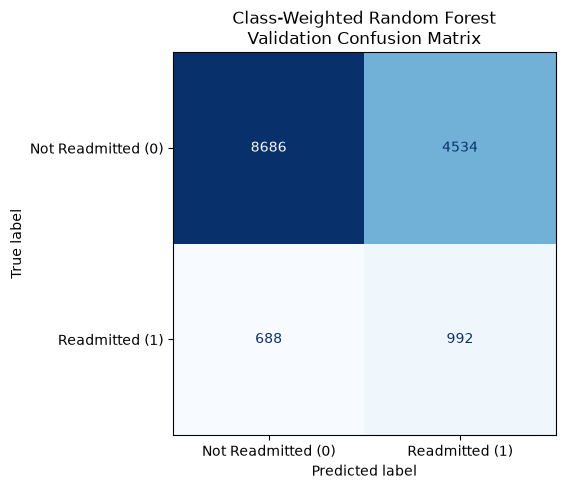

Class-Weighted Random Forest — Validation Results
----------------------------------------------------------------------

Model configuration:
Model: RandomForestClassifier
Number of trees: 200
Maximum depth: 12
Minimum samples per split: 100
Minimum samples per leaf: 50
Max features: sqrt
Class weight: balanced_subsample
Decision threshold: 0.50
Training time: 5.20 seconds

Confusion matrix:
Rows = actual [0, 1]; columns = predicted [0, 1]
[[8686 4534]
 [ 688  992]]

Validation metrics:
accuracy                    0.6495
balanced_accuracy           0.6238
precision                   0.1795
recall_sensitivity          0.5905
specificity                 0.6570
f1_score                    0.2753
roc_auc                     0.6717
pr_auc                      0.2175
predicted_positive_rate     0.3709
true_negatives           8686.0000
false_positives          4534.0000
false_negatives           688.0000
true_positives            992.0000

Baseline + Candidate Model Comparison:
            

In [7]:
# Step 3: Train and evaluate class-weighted Random Forest

import time
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Define the Random Forest candidate model

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    criterion="gini",
    max_depth=12,
    min_samples_split=100,
    min_samples_leaf=50,
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

# 2. Fit using training data only

training_start_time = time.perf_counter()

random_forest_model.fit(
    X_train_preprocessed,
    y_train
)

random_forest_training_time = (
    time.perf_counter() - training_start_time
)

# 3. Generate validation predictions and probabilities

random_forest_predictions = random_forest_model.predict(
    X_validation_preprocessed
)

random_forest_positive_class_index = list(
    random_forest_model.classes_
).index(1)

random_forest_probabilities = (
    random_forest_model.predict_proba(
        X_validation_preprocessed
    )[:, random_forest_positive_class_index]
)

# 4. Evaluate validation performance

random_forest_results = evaluate_binary_classifier(
    model_name="Random Forest - Class Weighted",
    y_true=y_validation,
    y_pred=random_forest_predictions,
    y_probability=random_forest_probabilities
)

random_forest_results[
    "training_time_seconds"
] = random_forest_training_time

random_forest_results[
    "n_estimators"
] = random_forest_model.n_estimators

random_forest_results[
    "max_depth"
] = random_forest_model.max_depth

random_forest_confusion_matrix = confusion_matrix(
    y_validation,
    random_forest_predictions,
    labels=[0, 1]
)

# 5. Display confusion matrix image

fig, ax = plt.subplots(figsize=(6, 5))

random_forest_display = ConfusionMatrixDisplay(
    confusion_matrix=random_forest_confusion_matrix,
    display_labels=[
        "Not Readmitted (0)",
        "Readmitted (1)"
    ]
)

random_forest_display.plot(
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax
)

ax.set_title(
    "Class-Weighted Random Forest\n"
    "Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

# 6. Display compact validation results

print("Class-Weighted Random Forest — Validation Results")
print("-" * 70)

print("\nModel configuration:")
print("Model: RandomForestClassifier")
print("Number of trees: 200")
print("Maximum depth: 12")
print("Minimum samples per split: 100")
print("Minimum samples per leaf: 50")
print("Max features: sqrt")
print("Class weight: balanced_subsample")
print("Decision threshold: 0.50")
print(f"Training time: {random_forest_training_time:.2f} seconds")

print("\nConfusion matrix:")
print("Rows = actual [0, 1]; columns = predicted [0, 1]")
print(random_forest_confusion_matrix)

print("\nValidation metrics:")

display_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
    "true_negatives",
    "false_positives",
    "false_negatives",
    "true_positives",
]

print(
    random_forest_results[
        display_columns
    ]
    .round(4)
    .T
    .to_string(header=False)
)

# 7. Compare Random Forest with Notebook 4 baselines

candidate_model_comparison = pd.concat(
    [
        baseline_model_comparison,
        random_forest_results
    ],
    ignore_index=True
)

comparison_columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

print("\nBaseline + Candidate Model Comparison:")

print(
    candidate_model_comparison[
        comparison_columns
    ]
    .sort_values(
        by="balanced_accuracy",
        ascending=False
    )
    .round(4)
    .to_string(index=False)
)

print("\nTest set status:")
print("- Test data remains untouched.")
print("- Evaluation used validation data only.")

In [8]:
# Compact Random Forest metrics

display_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
    "true_negatives",
    "false_positives",
    "false_negatives",
    "true_positives",
]

print("Random Forest — Compact Validation Metrics")
print("-" * 60)

print(
    random_forest_results[display_columns]
    .round(4)
    .T
    .to_string(header=False)
)

Random Forest — Compact Validation Metrics
------------------------------------------------------------
accuracy                    0.6495
balanced_accuracy           0.6238
precision                   0.1795
recall_sensitivity          0.5905
specificity                 0.6570
f1_score                    0.2753
roc_auc                     0.6717
pr_auc                      0.2175
predicted_positive_rate     0.3709
true_negatives           8686.0000
false_positives          4534.0000
false_negatives           688.0000
true_positives            992.0000


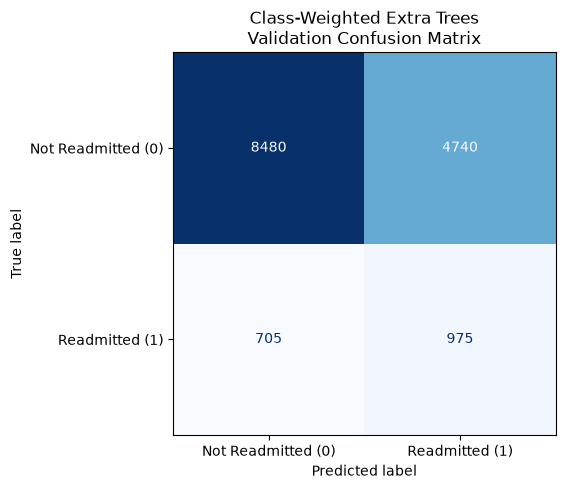

Class-Weighted Extra Trees — Validation Results
----------------------------------------------------------------------

Model configuration:
Model: ExtraTreesClassifier
Number of trees: 200
Maximum depth: 12
Minimum samples per split: 100
Minimum samples per leaf: 50
Max features: sqrt
Class weight: balanced
Decision threshold: 0.50
Training time: 4.37 seconds

Confusion matrix:
Rows = actual [0, 1]; columns = predicted [0, 1]
[[8480 4740]
 [ 705  975]]

Validation metrics:
accuracy                    0.6346
balanced_accuracy           0.6109
precision                   0.1706
recall_sensitivity          0.5804
specificity                 0.6415
f1_score                    0.2637
roc_auc                     0.6564
pr_auc                      0.2093
predicted_positive_rate     0.3836
true_negatives           8480.0000
false_positives          4740.0000
false_negatives           705.0000
true_positives            975.0000

Baseline + Candidate Model Comparison:
                          

In [9]:
# Step 4: Train and evaluate class-weighted Extra Trees

import time
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Define the Extra Trees candidate model

extra_trees_model = ExtraTreesClassifier(
    n_estimators=200,
    criterion="gini",
    max_depth=12,
    min_samples_split=100,
    min_samples_leaf=50,
    max_features="sqrt",
    bootstrap=False,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

# 2. Fit using training data only

training_start_time = time.perf_counter()

extra_trees_model.fit(
    X_train_preprocessed,
    y_train
)

extra_trees_training_time = (
    time.perf_counter() - training_start_time
)

# 3. Generate validation predictions and probabilities

extra_trees_predictions = extra_trees_model.predict(
    X_validation_preprocessed
)

extra_trees_positive_class_index = list(
    extra_trees_model.classes_
).index(1)

extra_trees_probabilities = (
    extra_trees_model.predict_proba(
        X_validation_preprocessed
    )[:, extra_trees_positive_class_index]
)

# 4. Evaluate validation performance

extra_trees_results = evaluate_binary_classifier(
    model_name="Extra Trees - Class Weighted",
    y_true=y_validation,
    y_pred=extra_trees_predictions,
    y_probability=extra_trees_probabilities
)

extra_trees_results[
    "training_time_seconds"
] = extra_trees_training_time

extra_trees_results[
    "n_estimators"
] = extra_trees_model.n_estimators

extra_trees_results[
    "max_depth"
] = extra_trees_model.max_depth

extra_trees_confusion_matrix = confusion_matrix(
    y_validation,
    extra_trees_predictions,
    labels=[0, 1]
)

# 5. Display confusion matrix image

fig, ax = plt.subplots(figsize=(6, 5))

extra_trees_display = ConfusionMatrixDisplay(
    confusion_matrix=extra_trees_confusion_matrix,
    display_labels=[
        "Not Readmitted (0)",
        "Readmitted (1)"
    ]
)

extra_trees_display.plot(
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax
)

ax.set_title(
    "Class-Weighted Extra Trees\n"
    "Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

# 6. Display compact validation results

print("Class-Weighted Extra Trees — Validation Results")
print("-" * 70)

print("\nModel configuration:")
print("Model: ExtraTreesClassifier")
print("Number of trees: 200")
print("Maximum depth: 12")
print("Minimum samples per split: 100")
print("Minimum samples per leaf: 50")
print("Max features: sqrt")
print("Class weight: balanced")
print("Decision threshold: 0.50")
print(f"Training time: {extra_trees_training_time:.2f} seconds")

print("\nConfusion matrix:")
print("Rows = actual [0, 1]; columns = predicted [0, 1]")
print(extra_trees_confusion_matrix)

print("\nValidation metrics:")

display_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
    "true_negatives",
    "false_positives",
    "false_negatives",
    "true_positives",
]

print(
    extra_trees_results[
        display_columns
    ]
    .round(4)
    .T
    .to_string(header=False)
)

# 7. Compare with previous models

candidate_model_comparison = pd.concat(
    [
        baseline_model_comparison,
        random_forest_results,
        extra_trees_results
    ],
    ignore_index=True
)

comparison_columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

print("\nBaseline + Candidate Model Comparison:")

print(
    candidate_model_comparison[
        comparison_columns
    ]
    .sort_values(
        by="balanced_accuracy",
        ascending=False
    )
    .round(4)
    .to_string(index=False)
)

print("\nTest set status:")
print("- Test data remains untouched.")
print("- Evaluation used validation data only.")

In [ ]:
# Compact Extra Trees metrics

display_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
    "true_negatives",
    "false_positives",
    "false_negatives",
    "true_positives",
]

print("Extra Trees — Compact Validation Metrics")
print("-" * 60)

print(
    extra_trees_results[display_columns]
    .round(4)
    .T
    .to_string(header=False)
)

Extra Trees — Compact Validation Metrics
------------------------------------------------------------
accuracy                    0.6346
balanced_accuracy           0.6109
precision                   0.1706
recall_sensitivity          0.5804
specificity                 0.6415
f1_score                    0.2637
roc_auc                     0.6564
pr_auc                      0.2093
predicted_positive_rate     0.3836
true_negatives           8480.0000
false_positives          4740.0000
false_negatives           705.0000
true_positives            975.0000


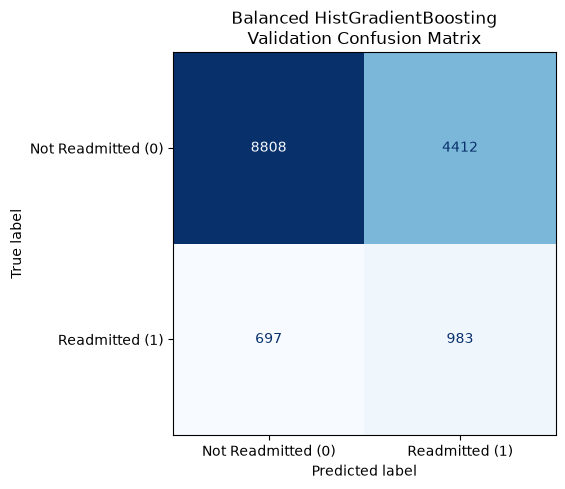

Balanced HistGradientBoosting — Validation Results
----------------------------------------------------------------------

Model configuration:
Model: HistGradientBoostingClassifier
Loss: log_loss
Learning rate: 0.05
Maximum iterations: 200
Iterations used: 139
Max leaf nodes: 31
Minimum samples per leaf: 50
L2 regularization: 0.1
Class imbalance handling: balanced sample weights
Decision threshold: 0.50
Training time: 6.72 seconds

Dense matrix shapes:
X_train_hgb: (69467, 179)
X_validation_hgb: (14900, 179)

Confusion matrix:
Rows = actual [0, 1]; columns = predicted [0, 1]
[[8808 4412]
 [ 697  983]]

Validation metrics:
accuracy                    0.6571
balanced_accuracy           0.6257
precision                   0.1822
recall_sensitivity          0.5851
specificity                 0.6663
f1_score                    0.2779
roc_auc                     0.6766
pr_auc                      0.2396
predicted_positive_rate     0.3621
true_negatives           8808.0000
false_positives    

In [11]:
# Step 5: Train and evaluate balanced HistGradientBoosting

import time
import numpy as np
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Convert sparse matrices to dense format for HistGradientBoosting

# HistGradientBoostingClassifier requires dense input.
# This is safe here because the matrix is only 69,467 x 179.

if sparse.issparse(X_train_preprocessed):
    X_train_hgb = X_train_preprocessed.toarray().astype(np.float32)
else:
    X_train_hgb = np.asarray(X_train_preprocessed).astype(np.float32)

if sparse.issparse(X_validation_preprocessed):
    X_validation_hgb = X_validation_preprocessed.toarray().astype(np.float32)
else:
    X_validation_hgb = np.asarray(X_validation_preprocessed).astype(np.float32)

# 2. Create balanced sample weights using training labels only

hgb_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# 3. Define the gradient boosting candidate model

hist_gradient_boosting_model = HistGradientBoostingClassifier(
    loss="log_loss",
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=31,
    min_samples_leaf=50,
    l2_regularization=0.1,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

# 4. Fit using training data only

training_start_time = time.perf_counter()

hist_gradient_boosting_model.fit(
    X_train_hgb,
    y_train,
    sample_weight=hgb_sample_weights
)

hgb_training_time = time.perf_counter() - training_start_time

# 5. Generate validation predictions and probabilities

hgb_predictions = hist_gradient_boosting_model.predict(
    X_validation_hgb
)

hgb_positive_class_index = list(
    hist_gradient_boosting_model.classes_
).index(1)

hgb_probabilities = (
    hist_gradient_boosting_model.predict_proba(
        X_validation_hgb
    )[:, hgb_positive_class_index]
)

# 6. Evaluate validation performance

hgb_results = evaluate_binary_classifier(
    model_name="HistGradientBoosting - Balanced Weights",
    y_true=y_validation,
    y_pred=hgb_predictions,
    y_probability=hgb_probabilities
)

hgb_results["training_time_seconds"] = hgb_training_time
hgb_results["iterations_used"] = hist_gradient_boosting_model.n_iter_

hgb_confusion_matrix = confusion_matrix(
    y_validation,
    hgb_predictions,
    labels=[0, 1]
)

# 7. Display confusion matrix image

fig, ax = plt.subplots(figsize=(6, 5))

hgb_display = ConfusionMatrixDisplay(
    confusion_matrix=hgb_confusion_matrix,
    display_labels=[
        "Not Readmitted (0)",
        "Readmitted (1)"
    ]
)

hgb_display.plot(
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax
)

ax.set_title(
    "Balanced HistGradientBoosting\n"
    "Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

# 8. Display compact validation results

print("Balanced HistGradientBoosting — Validation Results")
print("-" * 70)

print("\nModel configuration:")
print("Model: HistGradientBoostingClassifier")
print("Loss: log_loss")
print("Learning rate: 0.05")
print("Maximum iterations: 200")
print("Iterations used:", hist_gradient_boosting_model.n_iter_)
print("Max leaf nodes: 31")
print("Minimum samples per leaf: 50")
print("L2 regularization: 0.1")
print("Class imbalance handling: balanced sample weights")
print("Decision threshold: 0.50")
print(f"Training time: {hgb_training_time:.2f} seconds")

print("\nDense matrix shapes:")
print("X_train_hgb:", X_train_hgb.shape)
print("X_validation_hgb:", X_validation_hgb.shape)

print("\nConfusion matrix:")
print("Rows = actual [0, 1]; columns = predicted [0, 1]")
print(hgb_confusion_matrix)

print("\nValidation metrics:")

display_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
    "true_negatives",
    "false_positives",
    "false_negatives",
    "true_positives",
]

print(
    hgb_results[
        display_columns
    ]
    .round(4)
    .T
    .to_string(header=False)
)

# 9. Compare with baseline and candidate models so far

candidate_model_comparison = pd.concat(
    [
        baseline_model_comparison,
        random_forest_results,
        extra_trees_results,
        hgb_results
    ],
    ignore_index=True
)

comparison_columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

print("\nBaseline + Candidate Model Comparison:")

print(
    candidate_model_comparison[
        comparison_columns
    ]
    .sort_values(
        by="balanced_accuracy",
        ascending=False
    )
    .round(4)
    .to_string(index=False)
)

print("\nTest set status:")
print("- Test data remains untouched.")
print("- Evaluation used validation data only.")

In [12]:
# Compact HistGradientBoosting metrics

display_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
    "true_negatives",
    "false_positives",
    "false_negatives",
    "true_positives",
]

print("HistGradientBoosting — Compact Validation Metrics")
print("-" * 60)

print(
    hgb_results[display_columns]
    .round(4)
    .T
    .to_string(header=False)
)

HistGradientBoosting — Compact Validation Metrics
------------------------------------------------------------
accuracy                    0.6571
balanced_accuracy           0.6257
precision                   0.1822
recall_sensitivity          0.5851
specificity                 0.6663
f1_score                    0.2779
roc_auc                     0.6766
pr_auc                      0.2396
predicted_positive_rate     0.3621
true_negatives           8808.0000
false_positives          4412.0000
false_negatives           697.0000
true_positives            983.0000


In [13]:
# Step 6: Check available advanced boosting libraries

import importlib.util
import sys

# 1. Define libraries to check

libraries_to_check = {
    "xgboost": "XGBoost",
    "lightgbm": "LightGBM",
    "catboost": "CatBoost",
    "imblearn": "Imbalanced-learn"
}

available_libraries = {}
missing_libraries = {}

# 2. Check whether each package is installed

for package_name, display_name in libraries_to_check.items():
    package_spec = importlib.util.find_spec(package_name)

    if package_spec is not None:
        try:
            imported_package = importlib.import_module(package_name)
            package_version = getattr(
                imported_package,
                "__version__",
                "version not available"
            )

            available_libraries[package_name] = {
                "display_name": display_name,
                "version": package_version
            }

        except Exception as error:
            missing_libraries[package_name] = {
                "display_name": display_name,
                "reason": str(error)
            }

    else:
        missing_libraries[package_name] = {
            "display_name": display_name,
            "reason": "Package not installed"
        }

# 3. Select the recommended next model based on availability

if "xgboost" in available_libraries:
    recommended_next_model = "XGBoost"
    recommendation_reason = (
        "XGBoost is available and is a strong gradient-boosting "
        "candidate for tabular classification."
    )

elif "lightgbm" in available_libraries:
    recommended_next_model = "LightGBM"
    recommendation_reason = (
        "LightGBM is available and is a strong efficient "
        "gradient-boosting candidate."
    )

elif "catboost" in available_libraries:
    recommended_next_model = "CatBoost"
    recommendation_reason = (
        "CatBoost is available and is useful for categorical data, "
        "although our current matrix is already one-hot encoded."
    )

else:
    recommended_next_model = "No external boosting model available"
    recommendation_reason = (
        "We will continue using scikit-learn models and treat "
        "HistGradientBoosting as the main boosting candidate."
    )

# 4. Display availability results

print("Advanced Modeling Library Availability Check")
print("-" * 70)

print("\nPython executable:")
print(sys.executable)

print("\nAvailable libraries:")

if available_libraries:
    for package_name, details in available_libraries.items():
        print(
            f"- {details['display_name']} "
            f"({package_name}) version: {details['version']}"
        )
else:
    print("- None of the checked external libraries are available.")

print("\nMissing or unavailable libraries:")

if missing_libraries:
    for package_name, details in missing_libraries.items():
        print(
            f"- {details['display_name']} "
            f"({package_name}): {details['reason']}"
        )
else:
    print("- None")

print("\nRecommended next model:")
print(recommended_next_model)

print("\nReason:")
print(recommendation_reason)

print("\nNotebook 5 status:")
print("- Random Forest completed.")
print("- Extra Trees completed.")
print("- HistGradientBoosting completed.")
print("- Test set remains untouched.")

Advanced Modeling Library Availability Check
----------------------------------------------------------------------

Python executable:
c:\Users\pradh\anaconda3\envs\readmission_project\python.exe

Available libraries:
- XGBoost (xgboost) version: 3.2.0
- CatBoost (catboost) version: 1.2.10
- Imbalanced-learn (imblearn) version: 0.14.2

Missing or unavailable libraries:
- LightGBM (lightgbm): Package not installed

Recommended next model:
XGBoost

Reason:
XGBoost is available and is a strong gradient-boosting candidate for tabular classification.

Notebook 5 status:
- Random Forest completed.
- Extra Trees completed.
- HistGradientBoosting completed.
- Test set remains untouched.


Training class distribution:
Negative class count: 61,531
Positive class count: 7,936
scale_pos_weight: 7.7534


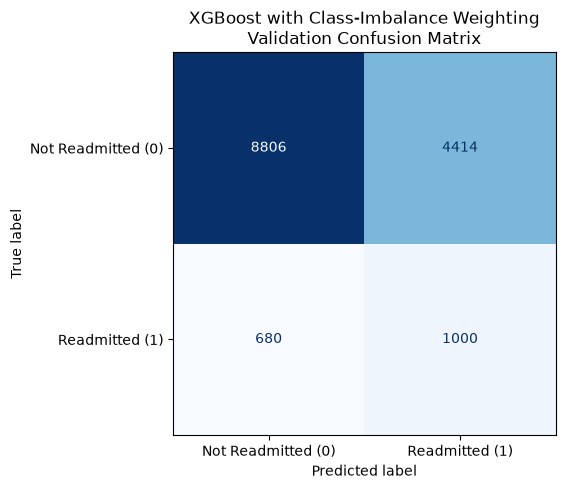

XGBoost — Validation Results
----------------------------------------------------------------------

Model configuration:
Model: XGBClassifier
Number of trees: 300
Learning rate: 0.05
Maximum depth: 4
Minimum child weight: 20
Subsample: 0.80
Column sample by tree: 0.80
Tree method: hist
Scale positive weight: 7.7534
Decision threshold: 0.50
Training time: 0.82 seconds

Confusion matrix:
Rows = actual [0, 1]; columns = predicted [0, 1]
[[8806 4414]
 [ 680 1000]]

Validation metrics:
accuracy                    0.6581
balanced_accuracy           0.6307
precision                   0.1847
recall_sensitivity          0.5952
specificity                 0.6661
f1_score                    0.2819
roc_auc                     0.6800
pr_auc                      0.2373
predicted_positive_rate     0.3634
true_negatives           8806.0000
false_positives          4414.0000
false_negatives           680.0000
true_positives           1000.0000

Baseline + Candidate Model Comparison:
                  

In [14]:
# Step 7: Train and evaluate XGBoost with class-imbalance weighting

import time
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Calculate class-imbalance weight using training labels only

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

xgb_scale_pos_weight = negative_count / positive_count

print("Training class distribution:")
print(f"Negative class count: {negative_count:,}")
print(f"Positive class count: {positive_count:,}")
print(f"scale_pos_weight: {xgb_scale_pos_weight:.4f}")

# 2. Define the XGBoost candidate model

xgboost_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=20,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=xgb_scale_pos_weight,
    n_jobs=-1,
    random_state=42
)

# 3. Fit using training data only

training_start_time = time.perf_counter()

xgboost_model.fit(
    X_train_preprocessed,
    y_train
)

xgboost_training_time = (
    time.perf_counter() - training_start_time
)

# 4. Generate validation predictions and probabilities

xgboost_predictions = xgboost_model.predict(
    X_validation_preprocessed
)

xgboost_probabilities = (
    xgboost_model.predict_proba(
        X_validation_preprocessed
    )[:, 1]
)

# 5. Evaluate validation performance

xgboost_results = evaluate_binary_classifier(
    model_name="XGBoost - Scale Pos Weight",
    y_true=y_validation,
    y_pred=xgboost_predictions,
    y_probability=xgboost_probabilities
)

xgboost_results["training_time_seconds"] = xgboost_training_time
xgboost_results["scale_pos_weight"] = xgb_scale_pos_weight

xgboost_confusion_matrix = confusion_matrix(
    y_validation,
    xgboost_predictions,
    labels=[0, 1]
)

# 6. Display confusion matrix image

fig, ax = plt.subplots(figsize=(6, 5))

xgboost_display = ConfusionMatrixDisplay(
    confusion_matrix=xgboost_confusion_matrix,
    display_labels=[
        "Not Readmitted (0)",
        "Readmitted (1)"
    ]
)

xgboost_display.plot(
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax
)

ax.set_title(
    "XGBoost with Class-Imbalance Weighting\n"
    "Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

# 7. Display compact validation results

print("XGBoost — Validation Results")
print("-" * 70)

print("\nModel configuration:")
print("Model: XGBClassifier")
print("Number of trees: 300")
print("Learning rate: 0.05")
print("Maximum depth: 4")
print("Minimum child weight: 20")
print("Subsample: 0.80")
print("Column sample by tree: 0.80")
print("Tree method: hist")
print(f"Scale positive weight: {xgb_scale_pos_weight:.4f}")
print("Decision threshold: 0.50")
print(f"Training time: {xgboost_training_time:.2f} seconds")

print("\nConfusion matrix:")
print("Rows = actual [0, 1]; columns = predicted [0, 1]")
print(xgboost_confusion_matrix)

print("\nValidation metrics:")

display_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
    "true_negatives",
    "false_positives",
    "false_negatives",
    "true_positives",
]

print(
    xgboost_results[
        display_columns
    ]
    .round(4)
    .T
    .to_string(header=False)
)

# 8. Compare with baseline and candidate models so far

candidate_model_comparison = pd.concat(
    [
        baseline_model_comparison,
        random_forest_results,
        extra_trees_results,
        hgb_results,
        xgboost_results
    ],
    ignore_index=True
)

comparison_columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

print("\nBaseline + Candidate Model Comparison:")

print(
    candidate_model_comparison[
        comparison_columns
    ]
    .sort_values(
        by="balanced_accuracy",
        ascending=False
    )
    .round(4)
    .to_string(index=False)
)

print("\nTest set status:")
print("- Test data remains untouched.")
print("- Evaluation used validation data only.")

In [15]:
# Compact XGBoost metrics

display_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
    "true_negatives",
    "false_positives",
    "false_negatives",
    "true_positives",
]

print("XGBoost — Compact Validation Metrics")
print("-" * 60)

print(
    xgboost_results[display_columns]
    .round(4)
    .T
    .to_string(header=False)
)

XGBoost — Compact Validation Metrics
------------------------------------------------------------
accuracy                    0.6581
balanced_accuracy           0.6307
precision                   0.1847
recall_sensitivity          0.5952
specificity                 0.6661
f1_score                    0.2819
roc_auc                     0.6800
pr_auc                      0.2373
predicted_positive_rate     0.3634
true_negatives           8806.0000
false_positives          4414.0000
false_negatives           680.0000
true_positives           1000.0000


Training class distribution:
Negative class count: 61,531
Positive class count: 7,936
Positive class weight: 7.7534


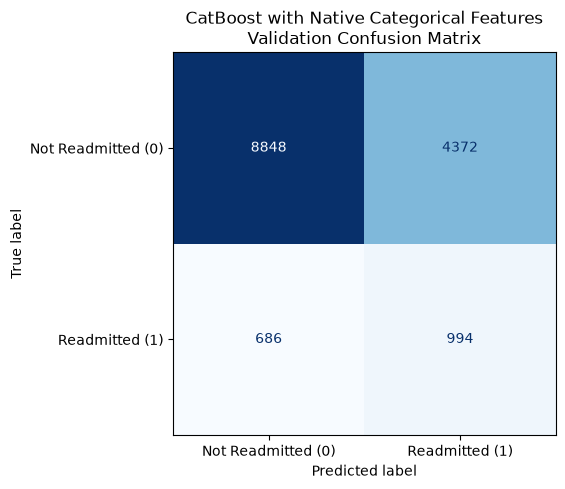

CatBoost — Validation Results
----------------------------------------------------------------------

Model configuration:
Model: CatBoostClassifier
Iterations: 300
Learning rate: 0.05
Depth: 4
L2 leaf regularization: 3.0
Loss function: Logloss
Evaluation metric: AUC
Categorical handling: Native CatBoost categorical handling
Categorical predictors: 35
Positive class weight: 7.7534
Decision threshold: 0.50
Training time: 35.70 seconds

Raw matrix shapes used by CatBoost:
X_train_catboost: (69467, 43)
X_validation_catboost: (14900, 43)

Confusion matrix:
Rows = actual [0, 1]; columns = predicted [0, 1]
[[8848 4372]
 [ 686  994]]

Validation metrics:
accuracy                    0.6605
balanced_accuracy           0.6305
precision                   0.1852
recall_sensitivity          0.5917
specificity                 0.6693
f1_score                    0.2821
roc_auc                     0.6781
pr_auc                      0.2367
predicted_positive_rate     0.3601
true_negatives           8848

In [16]:
# Step 8: Train and evaluate CatBoost with native categorical features

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Create CatBoost-specific raw train and validation data

# CatBoost can use categorical features directly.
# We will use raw 43 predictors, not the one-hot encoded 179-feature matrix.

X_train_catboost = X_train.copy()
X_validation_catboost = X_validation.copy()

# Convert categorical columns to strings for safe CatBoost handling
for column in CATEGORICAL_FEATURES:
    X_train_catboost[column] = X_train_catboost[column].astype(str)
    X_validation_catboost[column] = X_validation_catboost[column].astype(str)

# Make sure numeric columns are numeric
for column in NUMERIC_FEATURES:
    X_train_catboost[column] = pd.to_numeric(
        X_train_catboost[column],
        errors="raise"
    )
    X_validation_catboost[column] = pd.to_numeric(
        X_validation_catboost[column],
        errors="raise"
    )

# 2. Calculate class weights using training data only

catboost_negative_count = int((y_train == 0).sum())
catboost_positive_count = int((y_train == 1).sum())

catboost_positive_weight = (
    catboost_negative_count / catboost_positive_count
)

catboost_class_weights = [
    1.0,
    catboost_positive_weight
]

print("Training class distribution:")
print(f"Negative class count: {catboost_negative_count:,}")
print(f"Positive class count: {catboost_positive_count:,}")
print(f"Positive class weight: {catboost_positive_weight:.4f}")

# 3. Create CatBoost Pool objects

train_pool = Pool(
    data=X_train_catboost,
    label=y_train,
    cat_features=CATEGORICAL_FEATURES
)

validation_pool = Pool(
    data=X_validation_catboost,
    label=y_validation,
    cat_features=CATEGORICAL_FEATURES
)

# 4. Define the CatBoost candidate model

catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=3.0,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=catboost_class_weights,
    random_seed=42,
    verbose=False,
    allow_writing_files=False
)

# 5. Fit using training data only

training_start_time = time.perf_counter()

catboost_model.fit(
    train_pool
)

catboost_training_time = (
    time.perf_counter() - training_start_time
)

# 6. Generate validation predictions and probabilities

catboost_probabilities = (
    catboost_model.predict_proba(
        validation_pool
    )[:, 1]
)

catboost_predictions = (
    catboost_probabilities >= 0.50
).astype(int)

# 7. Evaluate validation performance

catboost_results = evaluate_binary_classifier(
    model_name="CatBoost - Native Categoricals",
    y_true=y_validation,
    y_pred=catboost_predictions,
    y_probability=catboost_probabilities
)

catboost_results["training_time_seconds"] = catboost_training_time
catboost_results["positive_class_weight"] = catboost_positive_weight

catboost_confusion_matrix = confusion_matrix(
    y_validation,
    catboost_predictions,
    labels=[0, 1]
)

# 8. Display confusion matrix image

fig, ax = plt.subplots(figsize=(6, 5))

catboost_display = ConfusionMatrixDisplay(
    confusion_matrix=catboost_confusion_matrix,
    display_labels=[
        "Not Readmitted (0)",
        "Readmitted (1)"
    ]
)

catboost_display.plot(
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax
)

ax.set_title(
    "CatBoost with Native Categorical Features\n"
    "Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

# 9. Display compact validation results

print("CatBoost — Validation Results")
print("-" * 70)

print("\nModel configuration:")
print("Model: CatBoostClassifier")
print("Iterations: 300")
print("Learning rate: 0.05")
print("Depth: 4")
print("L2 leaf regularization: 3.0")
print("Loss function: Logloss")
print("Evaluation metric: AUC")
print("Categorical handling: Native CatBoost categorical handling")
print(f"Categorical predictors: {len(CATEGORICAL_FEATURES)}")
print(f"Positive class weight: {catboost_positive_weight:.4f}")
print("Decision threshold: 0.50")
print(f"Training time: {catboost_training_time:.2f} seconds")

print("\nRaw matrix shapes used by CatBoost:")
print("X_train_catboost:", X_train_catboost.shape)
print("X_validation_catboost:", X_validation_catboost.shape)

print("\nConfusion matrix:")
print("Rows = actual [0, 1]; columns = predicted [0, 1]")
print(catboost_confusion_matrix)

print("\nValidation metrics:")

display_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
    "true_negatives",
    "false_positives",
    "false_negatives",
    "true_positives",
]

print(
    catboost_results[
        display_columns
    ]
    .round(4)
    .T
    .to_string(header=False)
)

# 10. Compare with baseline and candidate models so far

candidate_model_comparison = pd.concat(
    [
        baseline_model_comparison,
        random_forest_results,
        extra_trees_results,
        hgb_results,
        xgboost_results,
        catboost_results
    ],
    ignore_index=True
)

comparison_columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

print("\nBaseline + Candidate Model Comparison:")

print(
    candidate_model_comparison[
        comparison_columns
    ]
    .sort_values(
        by="balanced_accuracy",
        ascending=False
    )
    .round(4)
    .to_string(index=False)
)

print("\nTest set status:")
print("- Test data remains untouched.")
print("- CatBoost used raw train and validation predictors only.")
print("- Evaluation used validation data only.")

In [17]:
# Compact CatBoost metrics

display_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
    "true_negatives",
    "false_positives",
    "false_negatives",
    "true_positives",
]

print("CatBoost — Compact Validation Metrics")
print("-" * 60)

print(
    catboost_results[display_columns]
    .round(4)
    .T
    .to_string(header=False)
)

CatBoost — Compact Validation Metrics
------------------------------------------------------------
accuracy                    0.6605
balanced_accuracy           0.6305
precision                   0.1852
recall_sensitivity          0.5917
specificity                 0.6693
f1_score                    0.2821
roc_auc                     0.6781
pr_auc                      0.2367
predicted_positive_rate     0.3601
true_negatives           8848.0000
false_positives          4372.0000
false_negatives           686.0000
true_positives            994.0000


In [18]:
# Step 9: Create and save full candidate model comparison table

from pathlib import Path

# 1. Combine Notebook 4 baselines and Notebook 5 candidate models

candidate_model_comparison = pd.concat(
    [
        baseline_model_comparison,
        random_forest_results,
        extra_trees_results,
        hgb_results,
        xgboost_results,
        catboost_results,
    ],
    ignore_index=True
)

# 2. Select and organize important comparison columns

comparison_columns = [
    "model",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
    "true_negatives",
    "false_positives",
    "false_negatives",
    "true_positives",
]

candidate_model_comparison = (
    candidate_model_comparison[comparison_columns]
    .sort_values(
        by=[
            "balanced_accuracy",
            "f1_score",
            "roc_auc",
            "pr_auc",
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

# 3. Display comparison table in percentages

percentage_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
]

display_comparison = candidate_model_comparison.copy()

display_comparison[percentage_columns] = (
    display_comparison[percentage_columns] * 100
)

print("Notebook 5 Candidate Model Comparison — Validation Set")
print("-" * 110)

print(
    display_comparison[
        [
            "model",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall_sensitivity",
            "specificity",
            "f1_score",
            "roc_auc",
            "pr_auc",
        ]
    ]
    .round(2)
    .to_string(index=False)
)

# 4. Display confusion-matrix counts

print("\nConfusion-matrix counts:")
print(
    candidate_model_comparison[
        [
            "model",
            "true_negatives",
            "false_positives",
            "false_negatives",
            "true_positives",
        ]
    ]
    .astype(
        {
            "true_negatives": int,
            "false_positives": int,
            "false_negatives": int,
            "true_positives": int,
        }
    )
    .to_string(index=False)
)

# 5. Identify metric leaders

metrics_to_rank = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

print("\nValidation metric leaders:")

for metric in metrics_to_rank:
    best_row = candidate_model_comparison.loc[
        candidate_model_comparison[metric].idxmax()
    ]

    print(
        f"- {metric}: {best_row['model']} "
        f"({best_row[metric]:.4f})"
    )

# 6. Identify the current leading candidate model

leading_candidate_row = (
    candidate_model_comparison
    .sort_values(
        by=[
            "balanced_accuracy",
            "f1_score",
            "roc_auc",
            "pr_auc",
        ],
        ascending=False
    )
    .iloc[0]
)

leading_candidate_name = leading_candidate_row["model"]

print("\nCurrent leading candidate model:")
print(leading_candidate_name)

print("\nLeading candidate validation results:")
print(
    f"Balanced accuracy: "
    f"{leading_candidate_row['balanced_accuracy']:.4f}"
)
print(
    f"Recall: "
    f"{leading_candidate_row['recall_sensitivity']:.4f}"
)
print(
    f"Precision: "
    f"{leading_candidate_row['precision']:.4f}"
)
print(
    f"F1 score: "
    f"{leading_candidate_row['f1_score']:.4f}"
)
print(
    f"ROC-AUC: "
    f"{leading_candidate_row['roc_auc']:.4f}"
)
print(
    f"PR-AUC: "
    f"{leading_candidate_row['pr_auc']:.4f}"
)

# 7. Save the comparison table

METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics"
METRICS_PATH.mkdir(parents=True, exist_ok=True)

candidate_comparison_save_path = (
    METRICS_PATH
    / "notebook_5_candidate_model_comparison.csv"
)

candidate_model_comparison.to_csv(
    candidate_comparison_save_path,
    index=False
)

print("\nSaved output:")
print(candidate_comparison_save_path)

print("\nTest set status:")
print("- Test data remains untouched.")
print("- All comparisons use validation results only.")

Notebook 5 Candidate Model Comparison — Validation Set
--------------------------------------------------------------------------------------------------------------
                                  model  accuracy  balanced_accuracy  precision  recall_sensitivity  specificity  f1_score  roc_auc  pr_auc
             XGBoost - Scale Pos Weight     65.81              63.07      18.47               59.52        66.61     28.19    68.00   23.73
         CatBoost - Native Categoricals     66.05              63.05      18.52               59.17        66.93     28.21    67.81   23.67
HistGradientBoosting - Balanced Weights     65.71              62.57      18.22               58.51        66.63     27.79    67.66   23.96
         Random Forest - Class Weighted     64.95              62.38      17.95               59.05        65.70     27.53    67.17   21.75
   Logistic Regression - Class Weighted     66.98              62.01      18.29               55.60        68.43     27.52    66.94   

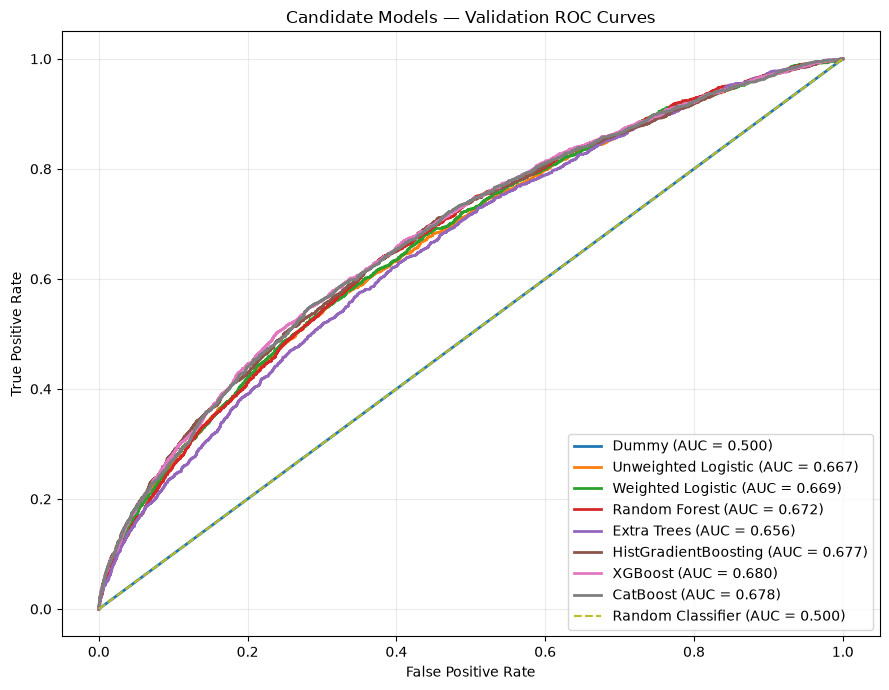

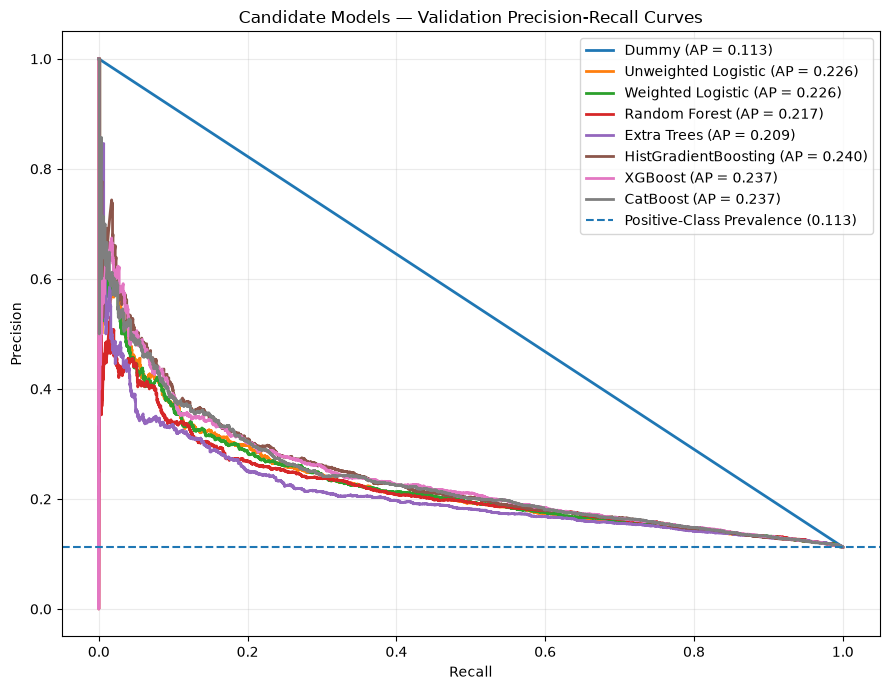

Candidate model validation curves created successfully.
----------------------------------------------------------------------

Saved ROC curve:
C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_5_candidate_roc_curves.png

Saved precision-recall curve:
C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_5_candidate_precision_recall_curves.png

Validation positive-class prevalence:
0.1128 (11.28%)

Models included:
- Dummy
- Unweighted Logistic
- Weighted Logistic
- Random Forest
- Extra Trees
- HistGradientBoosting
- XGBoost
- CatBoost

Test set status:
- Test data remains untouched.
- Curves use validation predictions only.


In [ ]:
# Step 10 Corrected: Create ROC and precision-recall curves

import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

# 1. Load Notebook 4 baseline models if needed

DUMMY_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "notebook_4_dummy_classifier.joblib"
)

WEIGHTED_LOGISTIC_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "notebook_4_logistic_class_weighted.joblib"
)

UNWEIGHTED_LOGISTIC_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "notebook_4_logistic_unweighted.joblib"
)

dummy_majority_model = joblib.load(DUMMY_MODEL_PATH)
weighted_logistic_model = joblib.load(WEIGHTED_LOGISTIC_MODEL_PATH)
logistic_baseline_model = joblib.load(UNWEIGHTED_LOGISTIC_MODEL_PATH)

# 2. Recreate baseline validation probabilities

dummy_validation_probabilities = (
    dummy_majority_model.predict_proba(
        X_validation_preprocessed
    )[:, 1]
)

weighted_logistic_probabilities = (
    weighted_logistic_model.predict_proba(
        X_validation_preprocessed
    )[:, 1]
)

logistic_validation_probabilities = (
    logistic_baseline_model.predict_proba(
        X_validation_preprocessed
    )[:, 1]
)

# 3. Collect validation probabilities from all completed models

model_probability_results = {
    "Dummy": dummy_validation_probabilities,
    "Unweighted Logistic": logistic_validation_probabilities,
    "Weighted Logistic": weighted_logistic_probabilities,
    "Random Forest": random_forest_probabilities,
    "Extra Trees": extra_trees_probabilities,
    "HistGradientBoosting": hgb_probabilities,
    "XGBoost": xgboost_probabilities,
    "CatBoost": catboost_probabilities,
}

FIGURES_PATH = PROJECT_ROOT / "outputs" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# 4. Plot ROC curves

fig, ax = plt.subplots(figsize=(9, 7))

for model_name, probabilities in model_probability_results.items():

    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_validation,
        probabilities
    )

    model_roc_auc = roc_auc_score(
        y_validation,
        probabilities
    )

    ax.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=f"{model_name} (AUC = {model_roc_auc:.3f})"
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier (AUC = 0.500)"
)

ax.set_title("Candidate Models — Validation ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(alpha=0.25)

plt.tight_layout()

candidate_roc_save_path = (
    FIGURES_PATH
    / "notebook_5_candidate_roc_curves.png"
)

plt.savefig(
    candidate_roc_save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 5. Plot precision-recall curves

fig, ax = plt.subplots(figsize=(9, 7))

for model_name, probabilities in model_probability_results.items():

    precision_values, recall_values, _ = precision_recall_curve(
        y_validation,
        probabilities
    )

    model_pr_auc = average_precision_score(
        y_validation,
        probabilities
    )

    ax.plot(
        recall_values,
        precision_values,
        linewidth=2,
        label=f"{model_name} (AP = {model_pr_auc:.3f})"
    )

validation_prevalence = y_validation.mean()

ax.axhline(
    y=validation_prevalence,
    linestyle="--",
    linewidth=1.5,
    label=(
        "Positive-Class Prevalence "
        f"({validation_prevalence:.3f})"
    )
)

ax.set_title("Candidate Models — Validation Precision-Recall Curves")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="upper right")
ax.grid(alpha=0.25)

plt.tight_layout()

candidate_pr_save_path = (
    FIGURES_PATH
    / "notebook_5_candidate_precision_recall_curves.png"
)

plt.savefig(
    candidate_pr_save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 6. Confirm saved figures

print("Candidate model validation curves created successfully.")
print("-" * 70)

print("\nSaved ROC curve:")
print(candidate_roc_save_path)

print("\nSaved precision-recall curve:")
print(candidate_pr_save_path)

print("\nValidation positive-class prevalence:")
print(f"{validation_prevalence:.4f} ({validation_prevalence:.2%})")

print("\nModels included:")
for model_name in model_probability_results.keys():
    print(f"- {model_name}")

print("\nTest set status:")
print("- Test data remains untouched.")
print("- Curves use validation predictions only.")

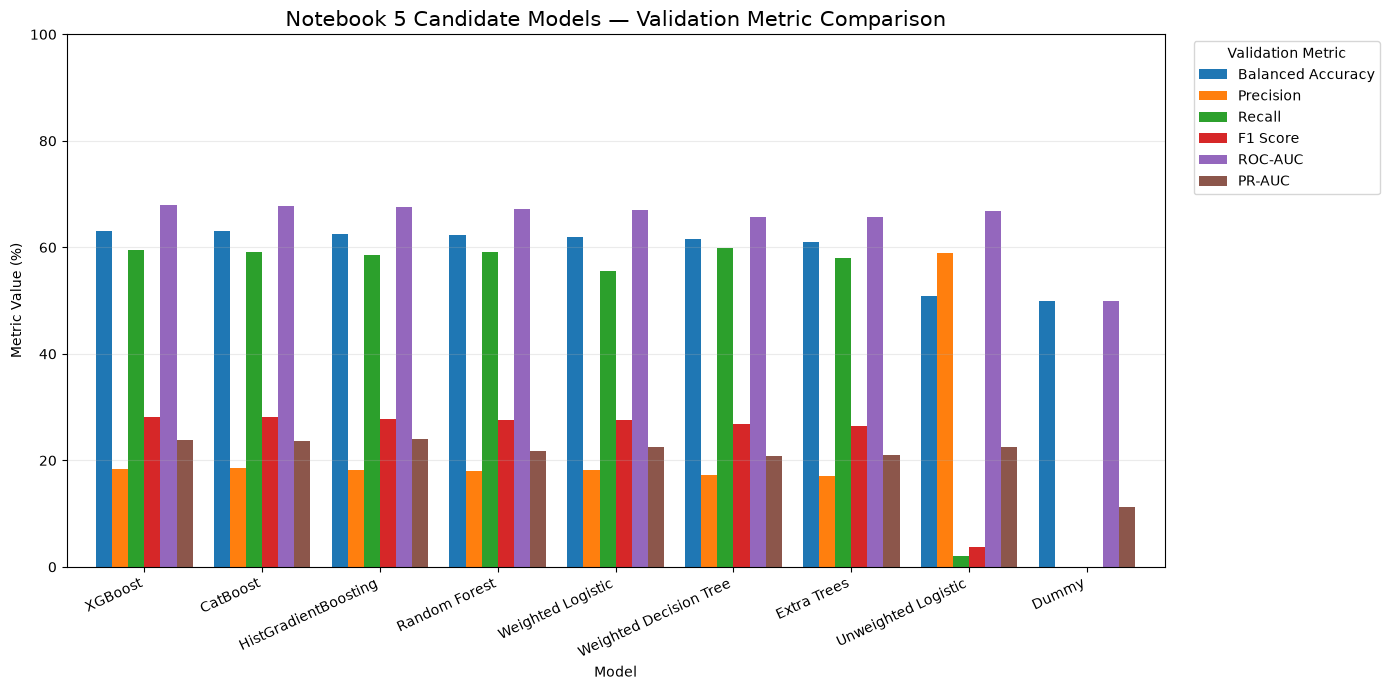

Candidate metric comparison chart created successfully.
----------------------------------------------------------------------

Saved figure:
C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_5_candidate_metric_comparison.png

Models included:
- XGBoost
- CatBoost
- HistGradientBoosting
- Random Forest
- Weighted Logistic
- Weighted Decision Tree
- Extra Trees
- Unweighted Logistic
- Dummy

Metrics included:
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC

Current leading candidates:
- XGBoost: best balanced accuracy and ROC-AUC
- HistGradientBoosting: best PR-AUC
- CatBoost: strong F1 score and fewer false positives

Test set status:
- Test data remains untouched.
- Chart uses validation results only.


In [22]:
# Step 11: Create and save candidate metric comparison chart

import matplotlib.pyplot as plt

# 1. Select important validation metrics

chart_metrics = [
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

model_label_map = {
    "Dummy - Most Frequent Class": "Dummy",
    "Logistic Regression - Unweighted": "Unweighted Logistic",
    "Logistic Regression - Class Weighted": "Weighted Logistic",
    "Decision Tree - Class Weighted": "Weighted Decision Tree",
    "Random Forest - Class Weighted": "Random Forest",
    "Extra Trees - Class Weighted": "Extra Trees",
    "HistGradientBoosting - Balanced Weights": "HistGradientBoosting",
    "XGBoost - Scale Pos Weight": "XGBoost",
    "CatBoost - Native Categoricals": "CatBoost",
}

# 2. Prepare chart data

chart_data = candidate_model_comparison[
    ["model"] + chart_metrics
].copy()

chart_data["model"] = (
    chart_data["model"]
    .map(model_label_map)
    .fillna(chart_data["model"])
)

# Convert to percentages
chart_data[chart_metrics] = chart_data[chart_metrics] * 100

chart_data = chart_data.set_index("model")

chart_data = chart_data.rename(
    columns={
        "balanced_accuracy": "Balanced Accuracy",
        "precision": "Precision",
        "recall_sensitivity": "Recall",
        "f1_score": "F1 Score",
        "roc_auc": "ROC-AUC",
        "pr_auc": "PR-AUC",
    }
)

# 3. Create grouped bar chart for all models

ax = chart_data.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.82
)

ax.set_title(
    "Notebook 5 Candidate Models — Validation Metric Comparison",
    fontsize=15
)

ax.set_xlabel("Model")
ax.set_ylabel("Metric Value (%)")
ax.set_ylim(0, 100)

ax.tick_params(
    axis="x",
    rotation=25
)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

ax.legend(
    title="Validation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

# 4. Save and display chart

FIGURES_PATH = PROJECT_ROOT / "outputs" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

candidate_metric_chart_path = (
    FIGURES_PATH
    / "notebook_5_candidate_metric_comparison.png"
)

plt.savefig(
    candidate_metric_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 5. Display confirmation

print("Candidate metric comparison chart created successfully.")
print("-" * 70)

print("\nSaved figure:")
print(candidate_metric_chart_path)

print("\nModels included:")
for model_name in chart_data.index:
    print(f"- {model_name}")

print("\nMetrics included:")
for metric_name in chart_data.columns:
    print(f"- {metric_name}")

print("\nCurrent leading candidates:")
print("- XGBoost: best balanced accuracy and ROC-AUC")
print("- HistGradientBoosting: best PR-AUC")
print("- CatBoost: strong F1 score and fewer false positives")

print("\nTest set status:")
print("- Test data remains untouched.")
print("- Chart uses validation results only.")

In [23]:
# Step 12: Save candidate models and completion metadata

import json
import joblib
from datetime import datetime

# 1. Create output directories

MODELS_PATH = PROJECT_ROOT / "models"
ARTIFACTS_PATH = PROJECT_ROOT / "artifacts"
METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics"

MODELS_PATH.mkdir(parents=True, exist_ok=True)
ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)
METRICS_PATH.mkdir(parents=True, exist_ok=True)

# 2. Define saved model paths

random_forest_save_path = (
    MODELS_PATH
    / "notebook_5_random_forest_class_weighted.joblib"
)

extra_trees_save_path = (
    MODELS_PATH
    / "notebook_5_extra_trees_class_weighted.joblib"
)

hgb_save_path = (
    MODELS_PATH
    / "notebook_5_hist_gradient_boosting_balanced.joblib"
)

xgboost_save_path = (
    MODELS_PATH
    / "notebook_5_xgboost_scale_pos_weight.json"
)

catboost_save_path = (
    MODELS_PATH
    / "notebook_5_catboost_native_categoricals.cbm"
)

metadata_save_path = (
    ARTIFACTS_PATH
    / "notebook_5_candidate_model_metadata.json"
)

completion_summary_path = (
    METRICS_PATH
    / "notebook_5_completion_summary.csv"
)

# 3. Save trained candidate models

joblib.dump(
    random_forest_model,
    random_forest_save_path
)

joblib.dump(
    extra_trees_model,
    extra_trees_save_path
)

joblib.dump(
    hist_gradient_boosting_model,
    hgb_save_path
)

# XGBoost and CatBoost are saved using their native formats
xgboost_model.save_model(
    xgboost_save_path
)

catboost_model.save_model(
    catboost_save_path
)

# 4. Identify leading candidate model

leading_candidate_row = (
    candidate_model_comparison
    .sort_values(
        by=[
            "balanced_accuracy",
            "f1_score",
            "roc_auc",
            "pr_auc"
        ],
        ascending=False
    )
    .iloc[0]
)

leading_candidate_name = leading_candidate_row["model"]

# 5. Define models recommended for next notebook

models_to_carry_forward = [
    "XGBoost - Scale Pos Weight",
    "CatBoost - Native Categoricals",
    "HistGradientBoosting - Balanced Weights",
]

# 6. Create metadata

candidate_metadata = {
    "notebook": "05_candidate_models.ipynb",
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "target_column": TARGET_COLUMN,
    "group_column": GROUP_COLUMN,
    "raw_feature_count": len(MODEL_FEATURES),
    "transformed_feature_count": EXPECTED_TRANSFORMED_FEATURES,
    "train_encounters": int(len(train_df)),
    "validation_encounters": int(len(validation_df)),
    "reserved_test_encounters": int(len(test_df)),
    "test_set_used": False,
    "baseline_reference_file": str(BASELINE_RESULTS_PATH),
    "candidate_models_evaluated": [
        "Random Forest - Class Weighted",
        "Extra Trees - Class Weighted",
        "HistGradientBoosting - Balanced Weights",
        "XGBoost - Scale Pos Weight",
        "CatBoost - Native Categoricals",
    ],
    "all_models_compared": candidate_model_comparison[
        "model"
    ].tolist(),
    "leading_candidate_model": leading_candidate_name,
    "models_to_carry_forward": models_to_carry_forward,
    "selection_basis": [
        "balanced_accuracy",
        "recall_sensitivity",
        "f1_score",
        "roc_auc",
        "pr_auc",
        "false_negatives",
        "false_positives"
    ],
    "saved_files": {
        "candidate_comparison_table": str(
            candidate_comparison_save_path
        ),
        "candidate_roc_curve": str(
            candidate_roc_save_path
        ),
        "candidate_precision_recall_curve": str(
            candidate_pr_save_path
        ),
        "candidate_metric_comparison_chart": str(
            candidate_metric_chart_path
        ),
        "random_forest_model": str(
            random_forest_save_path
        ),
        "extra_trees_model": str(
            extra_trees_save_path
        ),
        "hist_gradient_boosting_model": str(
            hgb_save_path
        ),
        "xgboost_model": str(
            xgboost_save_path
        ),
        "catboost_model": str(
            catboost_save_path
        ),
    }
}

with open(
    metadata_save_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        candidate_metadata,
        file,
        indent=4
    )

# 7. Save compact completion summary

completion_summary = pd.DataFrame(
    [
        {
            "notebook": "05_candidate_models.ipynb",
            "status": "Complete",
            "candidate_models_evaluated": 5,
            "total_models_compared": len(candidate_model_comparison),
            "leading_candidate_model": leading_candidate_name,
            "leading_accuracy": float(
                leading_candidate_row["accuracy"]
            ),
            "leading_balanced_accuracy": float(
                leading_candidate_row["balanced_accuracy"]
            ),
            "leading_precision": float(
                leading_candidate_row["precision"]
            ),
            "leading_recall": float(
                leading_candidate_row["recall_sensitivity"]
            ),
            "leading_f1_score": float(
                leading_candidate_row["f1_score"]
            ),
            "leading_roc_auc": float(
                leading_candidate_row["roc_auc"]
            ),
            "leading_pr_auc": float(
                leading_candidate_row["pr_auc"]
            ),
            "test_set_used": False,
            "models_to_carry_forward": "; ".join(
                models_to_carry_forward
            )
        }
    ]
)

completion_summary.to_csv(
    completion_summary_path,
    index=False
)

# 8. Confirm all important outputs exist

saved_paths = [
    random_forest_save_path,
    extra_trees_save_path,
    hgb_save_path,
    xgboost_save_path,
    catboost_save_path,
    metadata_save_path,
    completion_summary_path,
    candidate_comparison_save_path,
    candidate_roc_save_path,
    candidate_pr_save_path,
    candidate_metric_chart_path,
]

missing_saved_files = [
    str(path)
    for path in saved_paths
    if not path.exists()
]

if missing_saved_files:
    raise FileNotFoundError(
        "Some Notebook 5 outputs were not saved:\n"
        + "\n".join(missing_saved_files)
    )

# 9. Display completion information

print("Notebook 5 artifacts saved successfully.")
print("-" * 70)

print("\nLeading candidate model:")
print(leading_candidate_name)

print("\nLeading candidate validation results:")
print(
    f"Accuracy: "
    f"{leading_candidate_row['accuracy']:.4f}"
)
print(
    f"Balanced accuracy: "
    f"{leading_candidate_row['balanced_accuracy']:.4f}"
)
print(
    f"Precision: "
    f"{leading_candidate_row['precision']:.4f}"
)
print(
    f"Recall: "
    f"{leading_candidate_row['recall_sensitivity']:.4f}"
)
print(
    f"F1 score: "
    f"{leading_candidate_row['f1_score']:.4f}"
)
print(
    f"ROC-AUC: "
    f"{leading_candidate_row['roc_auc']:.4f}"
)
print(
    f"PR-AUC: "
    f"{leading_candidate_row['pr_auc']:.4f}"
)

print("\nModels recommended for tuning / threshold selection:")
for model_name in models_to_carry_forward:
    print(f"- {model_name}")

print("\nSaved model files:")
print(f"- {random_forest_save_path}")
print(f"- {extra_trees_save_path}")
print(f"- {hgb_save_path}")
print(f"- {xgboost_save_path}")
print(f"- {catboost_save_path}")

print("\nSaved documentation files:")
print(f"- {metadata_save_path}")
print(f"- {completion_summary_path}")
print(f"- {candidate_comparison_save_path}")

print("\nNotebook 5 status:")
print("- Candidate modeling completed.")
print("- Candidate model comparisons completed.")
print("- Candidate models and metadata saved.")
print("- Test set remains completely untouched.")

Notebook 5 artifacts saved successfully.
----------------------------------------------------------------------

Leading candidate model:
XGBoost - Scale Pos Weight

Leading candidate validation results:
Accuracy: 0.6581
Balanced accuracy: 0.6307
Precision: 0.1847
Recall: 0.5952
F1 score: 0.2819
ROC-AUC: 0.6800
PR-AUC: 0.2373

Models recommended for tuning / threshold selection:
- XGBoost - Scale Pos Weight
- CatBoost - Native Categoricals
- HistGradientBoosting - Balanced Weights

Saved model files:
- C:\Users\pradh\Documents\hospital-readmission-project\models\notebook_5_random_forest_class_weighted.joblib
- C:\Users\pradh\Documents\hospital-readmission-project\models\notebook_5_extra_trees_class_weighted.joblib
- C:\Users\pradh\Documents\hospital-readmission-project\models\notebook_5_hist_gradient_boosting_balanced.joblib
- C:\Users\pradh\Documents\hospital-readmission-project\models\notebook_5_xgboost_scale_pos_weight.json
- C:\Users\pradh\Documents\hospital-readmission-project\mod